# Feature-Group Ablation Analysis

## Objective
Analyse the contribution of each feature group (coherence, power, covariance) to (i) site classification and (ii) pathology LOSO under three ablation designs:
1. **full** — train on each group alone, using all its features
2. **leave-one-group-out** (no_*) — drop one group, train on the rest
3. **count-controlled** (sub_*) — randomly subsample each group to N=190 features (the size of the smallest group, covariance) and average over R random draws

The count-controlled design rules out feature-count as a confound, since coherence has ~10× more features than covariance or power.

In [1]:
import os
from pathlib import Path

if Path.cwd().name != 'eeg-site-effects':
    os.chdir('../..')
print('Working directory:', Path.cwd())

Working directory: /dmj/fizmed/kchorzela/licencjat/eeg-site-effects


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.visualization.style import apply_style
apply_style()

TABLE_DIR = 'results/tables/02_site_effect'
FIG_DIR   = 'results/figures/02_site_effect'
os.makedirs(FIG_DIR, exist_ok=True)

# Canonical ordering for display
from src.visualization.style import ABLATION_CONDITION_ORDER as CONDITION_ORDER

from src.visualization.style import GROUP_COLOR, MODEL_COLORS as MODEL_COLOR
DESIGN_HATCH = {'full': '', 'no': '//', 'sub': 'x'}

def design_of(cond):
    return cond.split('_', 1)[0]

def group_of(cond):
    return cond.split('_', 1)[1]

In [3]:
# Load all four (task × model) CSVs. LR-patho may be partial.
def load_safe(path):
    if Path(path).exists():
        df = pd.read_csv(path)
        return df if not df.empty else None
    return None

site_cb  = load_safe(f'{TABLE_DIR}/feature_ablation_site_catboost.csv')
site_lr  = load_safe(f'{TABLE_DIR}/feature_ablation_site_logreg.csv')
patho_cb = load_safe(f'{TABLE_DIR}/feature_ablation_patho_catboost.csv')
patho_lr = load_safe(f'{TABLE_DIR}/feature_ablation_patho_logreg.csv')

for name, d in [('site_cb', site_cb), ('site_lr', site_lr),
                ('patho_cb', patho_cb), ('patho_lr', patho_lr)]:
    if d is None:
        print(f'  {name}: MISSING')
    else:
        n_conds = d.condition.nunique()
        print(f'  {name}: {len(d):4d} rows, {n_conds} conditions, '
              f'seeds={sorted(d.seed.unique())}')

  site_cb:  135 rows, 9 conditions, seeds=[np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51)]
  site_lr:  135 rows, 9 conditions, seeds=[np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51)]
  patho_cb:  510 rows, 9 conditions, seeds=[np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46)]
  patho_lr:  510 rows, 9 conditions, seeds=[np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46)]


## 1. Per-condition aggregates

In [4]:
def aggregate(df, metric):
    """Return one row per condition: mean ± SD over all (fold/hospital × seed) rows."""
    if df is None: return None
    g = df.groupby('condition')[metric].agg(['mean', 'std', 'count']).round(4)
    n_feat = df.groupby('condition')['n_features'].first()
    n_seeds = df.groupby('condition')['seed'].nunique()
    out = g.copy()
    out['n_features'] = n_feat
    out['n_seeds']    = n_seeds
    out = out.reindex([c for c in CONDITION_ORDER if c in out.index])
    return out

print('=== SITE — overall MCC ===')
print('CatBoost:'); print(aggregate(site_cb, 'mcc_overall'))
print('\nLogReg:'); print(aggregate(site_lr, 'mcc_overall'))

=== SITE — overall MCC ===
CatBoost:
             mean     std  count  n_features  n_seeds
condition                                            
full_coh   0.8368  0.0028      5        2394        1
full_pow   0.5909  0.0060      5         266        1
full_cov   0.7351  0.0055      5         190        1
no_coh     0.7671  0.0043      5         456        1
no_pow     0.8433  0.0038      5        2584        1
no_cov     0.8479  0.0035      5        2660        1
sub_coh    0.8031  0.0055     50         190       10
sub_pow    0.5809  0.0051     50         190       10
sub_cov    0.7351  0.0055      5         190        1

LogReg:
             mean     std  count  n_features  n_seeds
condition                                            
full_coh   0.8239  0.0041      5        2394        1
full_pow   0.5358  0.0047      5         266        1
full_cov   0.7152  0.0045      5         190        1
no_coh     0.7561  0.0070      5         456        1
no_pow     0.8436  0.0061      5    

In [5]:
print('=== PATHO — LOSO AUC ===')
print('CatBoost:'); print(aggregate(patho_cb, 'auc'))
print('\nLogReg:'); print(aggregate(patho_lr, 'auc') if patho_lr is not None else '  (pending)')

print('\n=== PATHO — LOSO MCC ===')
print('CatBoost:'); print(aggregate(patho_cb, 'mcc'))
print('\nLogReg:'); print(aggregate(patho_lr, 'mcc') if patho_lr is not None else '  (pending)')

=== PATHO — LOSO AUC ===
CatBoost:
             mean     std  count  n_features  n_seeds
condition                                            
full_coh   0.7552  0.0496     30        2394        1
full_pow   0.7679  0.0570     30         266        1
full_cov   0.7625  0.0527     30         190        1
no_coh     0.7996  0.0526     30         456        1
no_pow     0.7913  0.0507     30        2584        1
no_cov     0.7816  0.0515     30        2660        1
sub_coh    0.7313  0.0495    150         190        5
sub_pow    0.7667  0.0553    150         190        5
sub_cov    0.7633  0.0530     30         190        1

LogReg:
             mean     std  count  n_features  n_seeds
condition                                            
full_coh   0.7513  0.0504     30        2394        1
full_pow   0.7298  0.0486     30         266        1
full_cov   0.7461  0.0580     30         190        1
no_coh     0.7733  0.0556     30         456        1
no_pow     0.7658  0.0541     30      

In [6]:
# Save consolidated summary CSV (one row per task × model × condition)
rows = []
for task, model, df, metric in [
    ('site',  'catboost', site_cb,  'mcc_overall'),
    ('site',  'logreg',   site_lr,  'mcc_overall'),
    ('patho', 'catboost', patho_cb, 'auc'),
    ('patho', 'logreg',   patho_lr, 'auc'),
]:
    if df is None: continue
    agg = aggregate(df, metric)
    for cond, row in agg.iterrows():
        rows.append({
            'task': task, 'model': model, 'condition': cond,
            'metric': 'mcc' if task == 'site' else 'auc',
            'n_features': int(row['n_features']),
            'n_seeds': int(row['n_seeds']),
            'mean': row['mean'], 'std': row['std'],
        })

summary = pd.DataFrame(rows)
summary_path = f'{TABLE_DIR}/feature_ablation_summary.csv'
summary.to_csv(summary_path, index=False)
print(f'saved {summary_path}  ({len(summary)} rows)')
summary.head(10)

saved results/tables/02_site_effect/feature_ablation_summary.csv  (36 rows)


,task,model,condition,metric,n_features,n_seeds,mean,std
0,site,catboost,full_coh,mcc,2394,1,0.8368,0.0028
1,site,catboost,full_pow,mcc,266,1,0.5909,0.0060
2,site,catboost,full_cov,mcc,190,1,0.7351,0.0055
3,site,catboost,no_coh,mcc,456,1,0.7671,0.0043
4,site,catboost,no_pow,mcc,2584,1,0.8433,0.0038
5,site,catboost,no_cov,mcc,2660,1,0.8479,0.0035
6,site,catboost,sub_coh,mcc,190,10,0.8031,0.0055
7,site,catboost,sub_pow,mcc,190,10,0.5809,0.0051
8,site,catboost,sub_cov,mcc,190,1,0.7351,0.0055
9,site,logreg,full_coh,mcc,2394,1,0.8239,0.0041


## 2. Site-classification bar chart — CB vs LR per condition

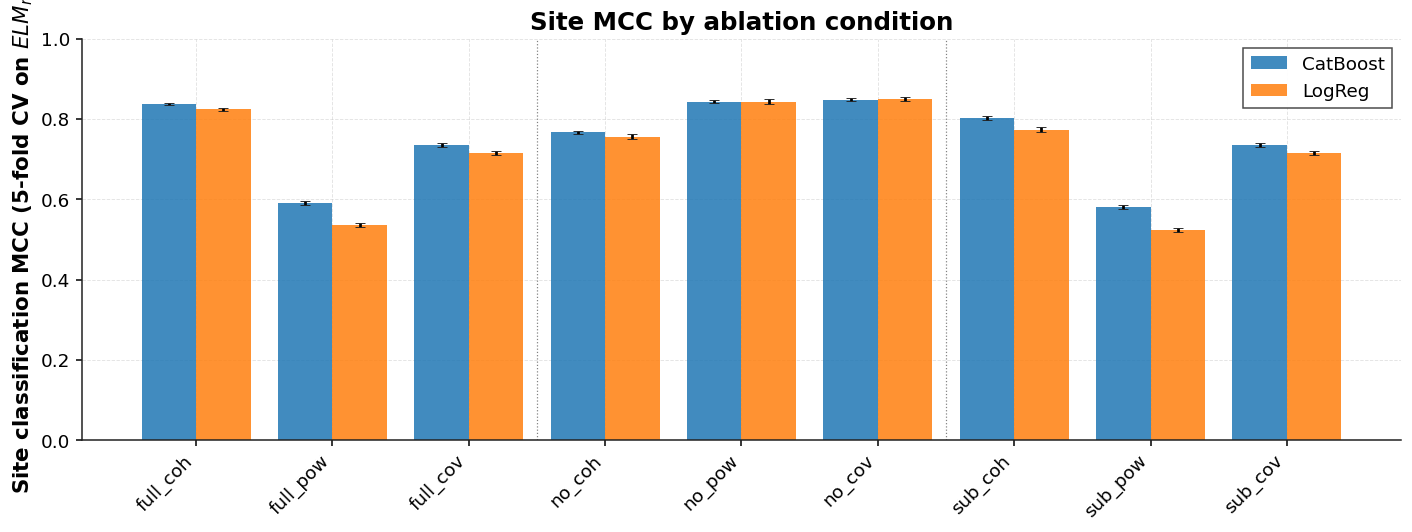

In [7]:
def bar_two_models(df_cb, df_lr, metric, ylabel, title, ylim, savename):
    """Side-by-side bars: CB and LR per condition."""
    conds = [c for c in CONDITION_ORDER if df_cb is not None and c in df_cb.condition.unique()]
    cb_mean = [df_cb[df_cb.condition == c][metric].mean() for c in conds]
    cb_std  = [df_cb[df_cb.condition == c][metric].std() for c in conds]
    lr_mean = [df_lr[df_lr.condition == c][metric].mean() if df_lr is not None and c in df_lr.condition.unique() else np.nan for c in conds]
    lr_std  = [df_lr[df_lr.condition == c][metric].std() if df_lr is not None and c in df_lr.condition.unique() else np.nan for c in conds]

    x = np.arange(len(conds))
    w = 0.4
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.bar(x - w/2, cb_mean, w, yerr=cb_std, label='CatBoost',
           color=MODEL_COLOR['catboost'], alpha=0.85, capsize=3)
    ax.bar(x + w/2, lr_mean, w, yerr=lr_std, label='LogReg',
           color=MODEL_COLOR['logreg'], alpha=0.85, capsize=3)
    ax.set_xticks(x); ax.set_xticklabels(conds, rotation=45, ha='right')
    ax.set_ylabel(ylabel); ax.set_title(title)
    if ylim: ax.set_ylim(*ylim)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.legend(loc='best')
    # mark design boundaries
    for boundary in [2.5, 5.5]:
        ax.axvline(boundary, color='gray', linestyle=':', linewidth=0.8)
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/{savename}', dpi=150, bbox_inches='tight')
    plt.show()

bar_two_models(site_cb, site_lr, 'mcc_overall',
               'Site classification MCC (5-fold CV on $ELM_n$)',
               'Site MCC by ablation condition',
               (0, 1), 'ablation_site_bar.png')

## 3. Pathology-LOSO bar chart — CB vs LR per condition

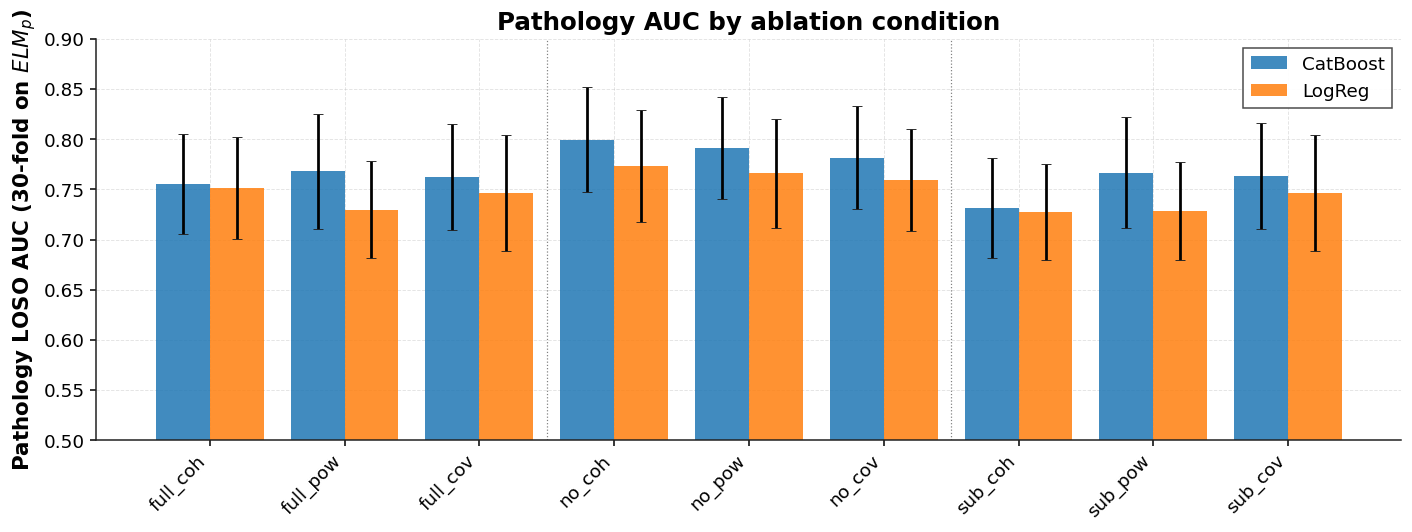

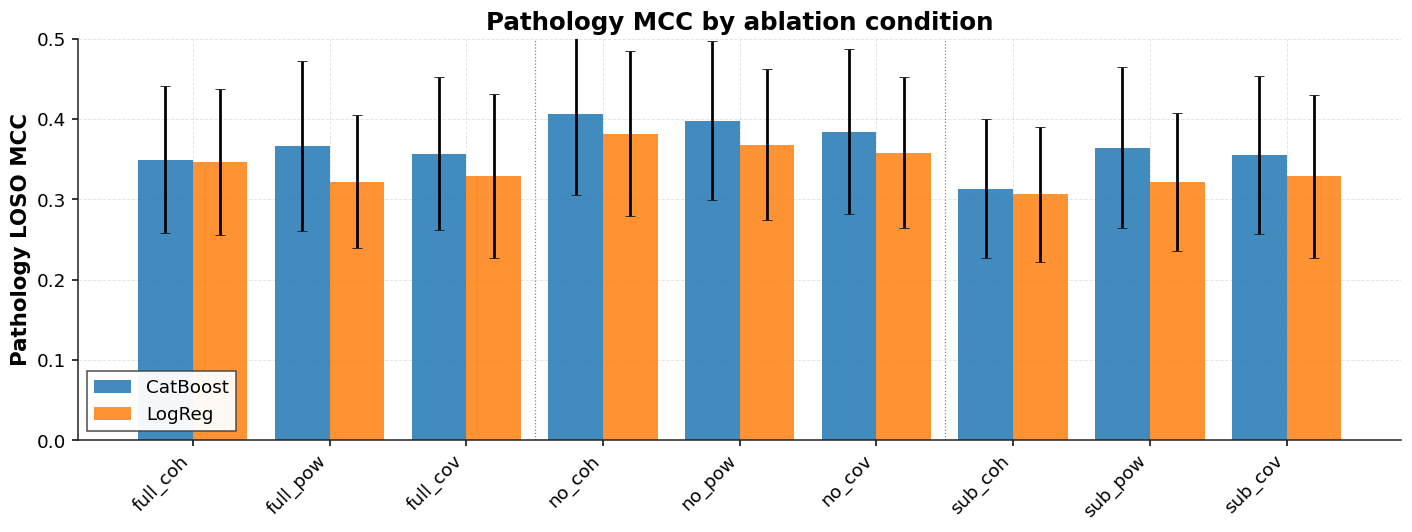

In [8]:
bar_two_models(patho_cb, patho_lr, 'auc',
               'Pathology LOSO AUC (30-fold on $ELM_p$)',
               'Pathology AUC by ablation condition',
               (0.5, 0.9), 'ablation_patho_bar_auc.png')

bar_two_models(patho_cb, patho_lr, 'mcc',
               'Pathology LOSO MCC',
               'Pathology MCC by ablation condition',
               (0, 0.5), 'ablation_patho_bar_mcc.png')

## 4. Cross-task dissociation — site MCC vs patho AUC (CatBoost only)

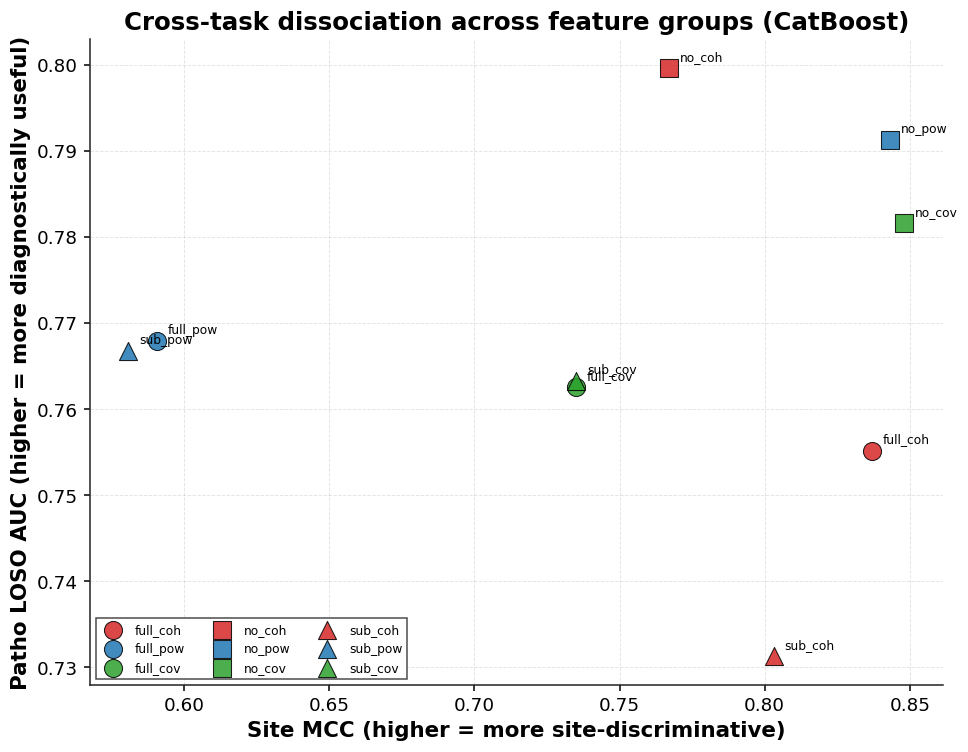

In [9]:
# For each condition, plot the (site MCC, patho AUC) coordinate.
# Bottom-right quadrant = informative for both tasks
# Top-left = site nuisance (high site MCC, low patho AUC)
fig, ax = plt.subplots(figsize=(9, 7))
for cond in CONDITION_ORDER:
    if cond not in site_cb.condition.unique() or cond not in patho_cb.condition.unique():
        continue
    s_mean = site_cb[site_cb.condition == cond]['mcc_overall'].mean()
    p_mean = patho_cb[patho_cb.condition == cond]['auc'].mean()
    grp = group_of(cond)
    design = design_of(cond)
    marker = {'full': 'o', 'no': 's', 'sub': '^'}[design]
    ax.scatter(s_mean, p_mean, s=140, color=GROUP_COLOR[grp], marker=marker,
               alpha=0.85, edgecolor='black', linewidth=0.7, label=cond)
    ax.annotate(cond, (s_mean, p_mean), xytext=(7, 5), textcoords='offset points', fontsize=8)

ax.set_xlabel('Site MCC (higher = more site-discriminative)')
ax.set_ylabel('Patho LOSO AUC (higher = more diagnostically useful)')
ax.set_title('Cross-task dissociation across feature groups (CatBoost)')
ax.grid(linestyle='--', alpha=0.4)
ax.legend(loc='lower left', fontsize=8, ncol=3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/ablation_cross_task_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Subsample variance check — how stable are sub_* across random seeds?

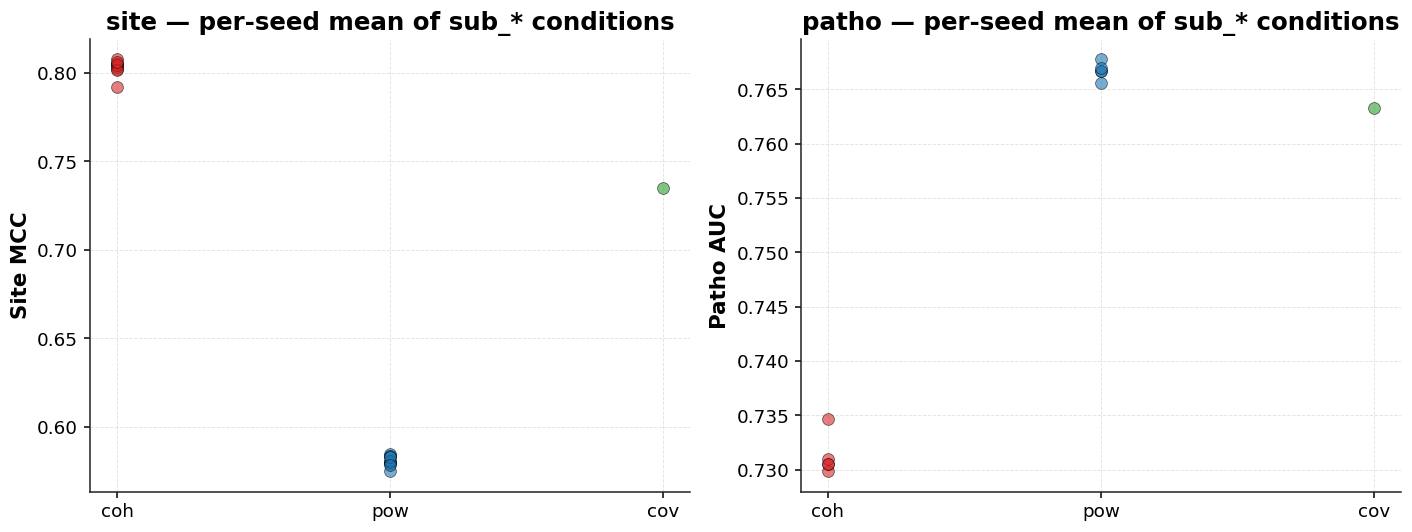

In [10]:
# For sub_coh and sub_pow, show variance across R random subsamples.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (task, df, metric, ylab) in zip(axes, [
    ('site',  site_cb,  'mcc_overall', 'Site MCC'),
    ('patho', patho_cb, 'auc',         'Patho AUC'),
]):
    for grp in ['coh', 'pow', 'cov']:
        cond = f'sub_{grp}'
        sub = df[df.condition == cond]
        if sub.empty: continue
        per_seed = sub.groupby('seed')[metric].mean()
        ax.scatter([grp]*len(per_seed), per_seed.values,
                   color=GROUP_COLOR[grp], alpha=0.6, s=60, edgecolor='black', linewidth=0.5)
    ax.set_ylabel(ylab)
    ax.set_title(f'{task} — per-seed mean of sub_* conditions')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/ablation_subsample_variance.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusions

*(Fill in after running)*

- **Site task**: coherence dominates per-feature, not just in aggregate. Subsample variance is tiny (~0.005-0.008 MCC across 10 random draws).
- **Patho task**: coherence is the *weakest* per-feature group; dropping it slightly improves LOSO AUC.
- **Cross-task dissociation** (the punchline): the same coherence features that carry the site signal contribute least to diagnostic performance. This supports a "coherence-as-site-nuisance" reading of the harmonisation paradox.